In [ ]:
!pip install compressai
!pip install pytorch-msssim
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.1 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from torchvision import transforms
from PIL import Image
from compressai.zoo import cheng2020_anchor
import numpy as np
from pytorch_msssim import ms_ssim
from torch.utils.data import DataLoader
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imágenes de validación cargadas: 100


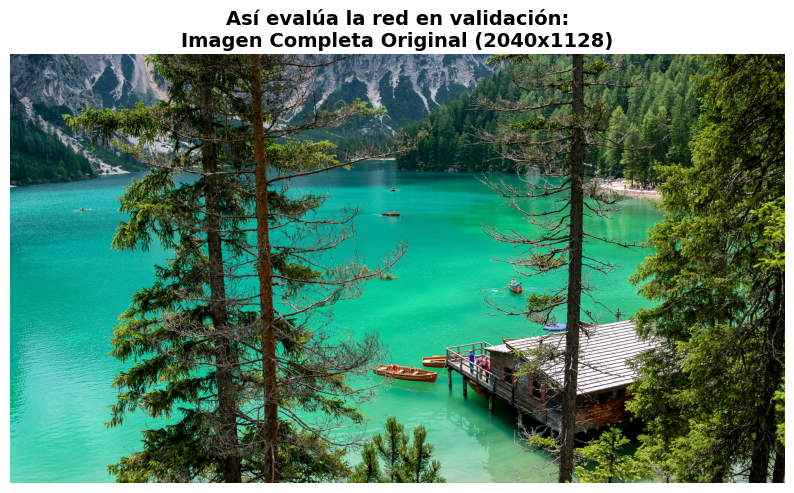

In [ ]:
# Dataset de Validación (Imagen Completa)
# Transformación para Validación: IMAGEN COMPLETA ORIGINAL
valid_transforms = transforms.Compose([
    transforms.ToTensor()
])

class ValidDatasetDIV2K(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_files = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert("RGB")
        return valid_transforms(img)

ruta_valid = "/content/drive/MyDrive/Curso4/TFG/DIV2K_HR_IMAGES/DIV2K_valid_HR"
valid_dataset = ValidDatasetDIV2K(ruta_valid)
# Batch_size = 1 es obligatorio porque las imágenes completas tienen tamaños distintos entre sí
valid_dataloader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
print(f"Imágenes de validación cargadas: {len(valid_dataset)}")

lote_val_ejemplo = next(iter(valid_dataloader))
imagen_val_visualizar = lote_val_ejemplo[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 6))
plt.imshow(imagen_val_visualizar)
plt.title(f"Así evalúa la red en validación:\nImagen Completa Original ({imagen_val_visualizar.shape[1]}x{imagen_val_visualizar.shape[0]})", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class AdaptiveCheng2020Anchor(nn.Module):
    def __init__(self, ranking_empirico=None):
        super().__init__()
        self.base_model = cheng2020_anchor(quality=3, pretrained=False)

        if ranking_empirico is None:
            self.register_buffer('ranking_empirico', torch.arange(128))
        else:
            self.register_buffer('ranking_empirico', ranking_empirico)

    def forward(self, x, active_channels_ratio):
        y = self.base_model.g_a(x)
        N = y.size(1)
        c_keep = int(N * active_channels_ratio)
        mask = torch.zeros_like(y)

        if c_keep > 0:
            canales_activos = self.ranking_empirico[:c_keep]
            mask[:, canales_activos, :, :] = 1.0

        y_masked = y * mask

        z = self.base_model.h_a(y_masked)
        z_hat, z_likelihoods = self.base_model.entropy_bottleneck(z)
        params = self.base_model.h_s(z_hat)

        y_hat = self.base_model.gaussian_conditional.quantize(y_masked, "dequantize")
        ctx_params = self.base_model.context_prediction(y_hat)
        gaussian_params = self.base_model.entropy_parameters(torch.cat((params, ctx_params), dim=1))
        scales_hat, means_hat = gaussian_params.chunk(2, 1)

        # --- INYECCIÓN DE MEDIAS DURANTE EL FORWARD ---
        y_for_likelihood = y_masked.clone()
        y_for_decoder = y_hat.clone()

        if c_keep < N:
            # Los canales inactivos son los que van desde c_keep hasta el final del ranking
            canales_inactivos = self.ranking_empirico[c_keep:]

            # Inyectamos la media predicha en las posiciones apagadas
            y_for_likelihood[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]
            y_for_decoder[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]

        # Calculamos probabilidades y reconstruimos usando los tensores corregidos
        _, y_likelihoods = self.base_model.gaussian_conditional(y_for_likelihood, scales_hat, means_hat)
        x_hat = self.base_model.g_s(y_for_decoder)

        # IMPORTANTE: Devolvemos 'y' (sin enmascarar) para que tu Loss pueda calcular la Energía (H y S)
        return {'x_hat': x_hat, 'likelihoods': {'y': y_likelihoods, 'z': z_likelihoods}, 'y': y}

In [ ]:
def calcular_ranking_empirico(modelo, dataloader, device):
    """Calcula qué canales tienen más energía media en el dataset de validación"""
    print("Perfilando el dataset de validación para extraer el ranking empírico...")

    # Aseguramos que el modelo esté en el dispositivo correcto y en modo evaluación
    modelo = modelo.to(device)
    modelo.eval()

    energia_total = None
    num_imagenes = 0

    with torch.no_grad():
        for lote in dataloader:
            # El dataloader devuelve directamente el tensor de la imagen (Batch, C, H, W)
            img = lote.to(device)

            # APLICAMOS PADDING DE SEGURIDAD
            # Como son imágenes completas, forzamos que sean múltiplo de 64
            _, _, h, w = img.size()
            pad_h = (64 - (h % 64)) % 64
            pad_w = (64 - (w % 64)) % 64
            img_padded = F.pad(img, (0, pad_w, 0, pad_h))

            # Detectamos si es el modelo original de CompressAI o el envoltorio adaptativo
            if hasattr(modelo, 'base_model'):
                y_puro = modelo.base_model.g_a(img_padded)
            else:
                y_puro = modelo.g_a(img_padded)

            # Calculamos la energía media absoluta por canal (destruyendo Batch, Alto y Ancho)
            energia_lote = torch.mean(torch.abs(y_puro), dim=(0, 2, 3))

            # Acumulamos
            if energia_total is None:
                energia_total = energia_lote
            else:
                energia_total += energia_lote
            num_imagenes += 1

    # Media global y cálculo del ranking
    energia_media_global = energia_total / num_imagenes
    ranking_indices = torch.argsort(energia_media_global, descending=True)

    print(f"Ranking calculado sobre {num_imagenes} imágenes.")
    print(f"Canal con MÁS energía: {ranking_indices[0].item()} | MENOR energía: {ranking_indices[-1].item()}")

    return ranking_indices

In [ ]:
ruta_guardado = '/content/drive/MyDrive/Curso4/TFG/CHENG2020_Q3_MSE_0018_1_H_01_S_005_DataDriven.pth'
ruta_imagen = '/content/drive/MyDrive/Curso4/TFG/DIV2K_HR_IMAGES/DIV2K_valid_HR/0843.png'

modelo_temporal=cheng2020_anchor(quality=3, pretrained=True)
ranking_empirico = calcular_ranking_empirico(modelo_temporal, valid_dataloader, device)
model = AdaptiveCheng2020Anchor(ranking_empirico=ranking_empirico).to(device)
model.load_state_dict(torch.load(ruta_guardado, map_location=device), strict=False)
model.eval()

img_pil = Image.open(ruta_imagen).convert('RGB')
test_image_original = transforms.ToTensor()(img_pil).unsqueeze(0).to(device)

Perfilando el dataset de validación para extraer el ranking empírico...
Ranking calculado sobre 100 imágenes.
Canal con MÁS energía: 119 | MENOR energía: 27


In [ ]:
def evaluar_codec_interactivo(ratio_canales):
    with torch.no_grad():
        _, _, h, w = test_image_original.size()
        pad_h = (64 - (h % 64)) % 64
        pad_w = (64 - (w % 64)) % 64
        img_padded = F.pad(test_image_original, (0, pad_w, 0, pad_h))

        # 1. Extraemos latentes puros
        y_puro = model.base_model.g_a(img_padded)
        N = y_puro.size(1)

        # 2. Calculamos la energía al vuelo de ESTA IMAGEN
        energia_canales = torch.mean(torch.abs(y_puro), dim=(0, 2, 3))

        # 3. EXTRAEMOS EL RANKING DINÁMICO
        # En lugar de usar model.ranking_empirico, ordenamos por la energía real de la foto actual
        ranking_energia_dinamico = torch.argsort(energia_canales, descending=True)

        c_keep = int(N * ratio_canales)

        # 4. Crear la máscara apagando los canales con MENOS energía de la foto actual
        mask = torch.ones_like(y_puro)
        if c_keep < N:
            canales_inactivos = ranking_energia_dinamico[c_keep:]
            mask[:, canales_inactivos, :, :] = 0.0

        y_masked = y_puro * mask

        # 5. Recreamos el paso manual para inyectar medias y saltarnos el ranking fijo del modelo
        z = model.base_model.h_a(y_masked)
        z_hat, z_likelihoods = model.base_model.entropy_bottleneck(z)
        params = model.base_model.h_s(z_hat)

        y_hat = model.base_model.gaussian_conditional.quantize(y_masked, "dequantize")
        ctx_params = model.base_model.context_prediction(y_hat)
        gaussian_params = model.base_model.entropy_parameters(torch.cat((params, ctx_params), dim=1))
        scales_hat, means_hat = gaussian_params.chunk(2, 1)

        y_for_likelihood = y_masked.clone()
        y_for_decoder = y_hat.clone()

        # Inyectamos las medias de los canales que acabamos de desactivar por falta de energía
        if c_keep < N:
            y_for_likelihood[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]
            y_for_decoder[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]

        _, y_likelihoods = model.base_model.gaussian_conditional(y_for_likelihood, scales_hat, means_hat)
        x_hat = model.base_model.g_s(y_for_decoder)

        # 6. Métricas de reconstrucción
        reconstruida_padded = x_hat.clamp(0, 1)
        reconstruida = reconstruida_padded[:, :, :h, :w]

        mse = torch.mean((test_image_original - reconstruida) ** 2)
        psnr = 10 * torch.log10(1.0 / mse)
        num_pixels = h * w

        # Usamos las probabilidades de nuestra pasada manual
        bpp = sum((torch.log(likelihoods).sum() / (-math.log(2) * num_pixels)) for likelihoods in [y_likelihoods, z_likelihoods])

        # ========================================================
        # 7. CONFIGURACIÓN DEL HEATMAP POR ENERGÍA
        # ========================================================
        energia_np = energia_canales.cpu().numpy()

        cols = 16
        rows = math.ceil(N / cols)

        # Matriz llena de NaN (saldrán en gris/apagados)
        matriz_energia = np.full(rows * cols, np.nan)

        if c_keep > 0:
            # Seleccionamos los índices activos basados en nuestro ranking dinámico
            canales_activos = ranking_energia_dinamico[:c_keep].cpu().numpy()
            for idx in canales_activos:
                matriz_energia[idx] = energia_np[idx]

        matriz_energia = matriz_energia.reshape((rows, cols))

        # ========================================================
        # 8. DIBUJO DE LAS GRÁFICAS
        # ========================================================
        img_orig_np = test_image_original[0].cpu().permute(1, 2, 0).numpy()
        img_recon_np = reconstruida[0].cpu().permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 1, 0.6]})

        ax[0].imshow(img_orig_np)
        ax[0].set_title(f"Original ({w}x{h})", fontsize=14)
        ax[0].axis('off')

        titulo_recon = f"Reconstruida | PSNR: {psnr:.2f} dB | Tasa: {bpp:.3f} bpp"
        ax[1].imshow(img_recon_np)
        ax[1].set_title(titulo_recon, fontsize=14, color='darkblue', fontweight='bold')
        ax[1].axis('off')

        cmap = plt.cm.magma.copy()
        cmap.set_bad(color='lightgray') # Color para los canales desactivados (NaN)

        # Fijamos el máximo al canal más fuerte de toda la imagen para no falsear los colores
        vmax_val = np.max(energia_np) + 0.1 if c_keep > 0 else 0.1

        im = ax[2].imshow(matriz_energia, cmap=cmap, aspect='equal', vmin=0, vmax=vmax_val)

        ax[2].set_xticks(np.arange(-.5, cols, 1), minor=True)
        ax[2].set_yticks(np.arange(-.5, rows, 1), minor=True)
        ax[2].grid(which='minor', color='w', linestyle='-', linewidth=1)
        ax[2].tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

        titulo_mapa = f"Energía de Canales Latentes\n(Matriz {rows}x{cols} = {N} Canales)"
        ax[2].set_title(titulo_mapa, fontsize=14, fontweight='bold')

        cbar = plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)
        cbar.set_label('Nivel de Activación (Energía)', rotation=270, labelpad=15)

        plt.tight_layout()
        plt.show()

deslizador = widgets.FloatSlider(value=1, min=0.01, max=1.0, step=0.01, description='Calidad:', continuous_update=False)
print("Mueve el deslizador para ver el descarte inteligente por energía de ESTA IMAGEN y la inyección de medias:")
widgets.interact(evaluar_codec_interactivo, ratio_canales=deslizador);

Mueve el deslizador para ver el descarte inteligente por energía de ESTA IMAGEN y la inyección de medias:


interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='Calidad:', max=1.0, min=0.0…

Evaluando los 128 puntos de la curva RD ordenados por energía de ESTA imagen...


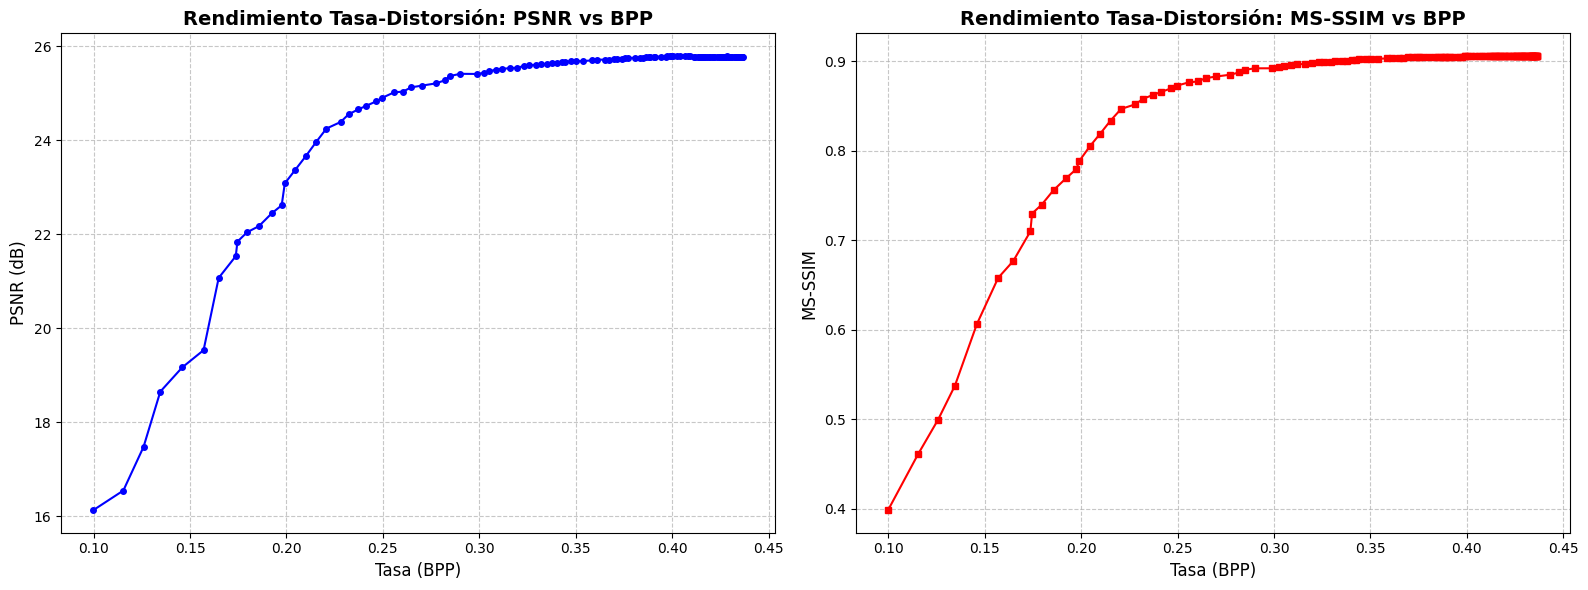

In [ ]:
bpp_list = []
psnr_list = []
msssim_list = []

model.eval()

with torch.no_grad():
    _, _, h, w = test_image_original.size()
    pad_h = (64 - (h % 64)) % 64
    pad_w = (64 - (w % 64)) % 64
    img_padded = F.pad(test_image_original, (0, pad_w, 0, pad_h))

    # 1. Extraemos latentes puros
    y_puro = model.base_model.g_a(img_padded)
    N = y_puro.size(1)

    # 2. Calculamos la energía al vuelo y extraemos el ranking dinámico
    energia_canales = torch.mean(torch.abs(y_puro), dim=(0, 2, 3))
    ranking_energia_dinamico = torch.argsort(energia_canales, descending=True)

    print(f"Evaluando los {N} puntos de la curva RD ordenados por energía de ESTA imagen...")

    for c_keep in range(1, N + 1):
        ratio = c_keep / float(N)

        # 3. Crear la máscara apagando los canales con MENOS energía
        mask = torch.ones_like(y_puro)
        if c_keep < N:
            canales_inactivos = ranking_energia_dinamico[c_keep:]
            mask[:, canales_inactivos, :, :] = 0.0

        y_masked = y_puro * mask

        # 4. Recreamos el paso manual para inyectar medias y saltarnos el ranking fijo del modelo
        z = model.base_model.h_a(y_masked)
        z_hat, z_likelihoods = model.base_model.entropy_bottleneck(z)
        params = model.base_model.h_s(z_hat)

        y_hat = model.base_model.gaussian_conditional.quantize(y_masked, "dequantize")
        ctx_params = model.base_model.context_prediction(y_hat)
        gaussian_params = model.base_model.entropy_parameters(torch.cat((params, ctx_params), dim=1))
        scales_hat, means_hat = gaussian_params.chunk(2, 1)

        y_for_likelihood = y_masked.clone()
        y_for_decoder = y_hat.clone()

        # Inyectamos las medias de los canales que acabamos de desactivar por falta de energía
        if c_keep < N:
            y_for_likelihood[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]
            y_for_decoder[:, canales_inactivos, :, :] = means_hat[:, canales_inactivos, :, :]

        _, y_likelihoods = model.base_model.gaussian_conditional(y_for_likelihood, scales_hat, means_hat)
        x_hat = model.base_model.g_s(y_for_decoder)

        # 5. Métricas de reconstrucción
        reconstruida_padded = x_hat.clamp(0, 1)
        reconstruida = reconstruida_padded[:, :, :h, :w]

        mse = torch.mean((test_image_original - reconstruida) ** 2)
        psnr = 10 * torch.log10(1.0 / mse)

        msssim_val = ms_ssim(reconstruida, test_image_original, data_range=1.0, size_average=True)

        num_pixels = h * w
        # Usamos las probabilidades de nuestra pasada manual
        bpp = sum((torch.log(likelihoods).sum() / (-math.log(2) * num_pixels)) for likelihoods in [y_likelihoods, z_likelihoods])

        bpp_list.append(bpp.item())
        psnr_list.append(psnr.item())
        msssim_list.append(msssim_val.item())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(bpp_list, psnr_list, marker='o', linestyle='-', color='b', markersize=4)
ax1.set_title('Rendimiento Tasa-Distorsión: PSNR vs BPP', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tasa (BPP)', fontsize=12)
ax1.set_ylabel('PSNR (dB)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(bpp_list, msssim_list, marker='s', linestyle='-', color='r', markersize=4)
ax2.set_title('Rendimiento Tasa-Distorsión: MS-SSIM vs BPP', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tasa (BPP)', fontsize=12)
ax2.set_ylabel('MS-SSIM', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()